## 图神经网络 (GNN)
这个模型将会读取 `gnn_data.pkl`，通过 GCN (图卷积神经网络) 提取分子的空间拓扑特征，最后由 MLP (多层感知机) 完成水溶性的回归预测。

In [1]:
import pickle
import torch
import numpy as np
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

class ESOLGNNDataset(Dataset):
    def __init__(self, pickle_file):
        super().__init__()
        with open(pickle_file, 'rb') as f:
            self.data_list = pickle.load(f)
            
    def len(self):
        return len(self.data_list)
        
    def get(self, idx):
        item = self.data_list[idx]
        
        # 节点特征：每个分子不同的原子特征 (如果在 feature_get 中已归一化这里直接读取)
        x = torch.tensor(item['x'], dtype=torch.float)
        
        # 图的边连接：邻接矩阵
        edge_index = torch.tensor(item['edge_index'], dtype=torch.long)
        if edge_index.numel() > 0:
            edge_index = edge_index.t().contiguous()
        else:
            edge_index = torch.empty((2,0), dtype=torch.long)
            
        # 真实标签 target
        y = torch.tensor([item['y']], dtype=torch.float)
        
        return Data(x=x, edge_index=edge_index, y=y)

dataset = ESOLGNNDataset('data/gnn_data.pkl')
train_size = int(len(dataset) * 0.8)
test_size = len(dataset) - train_size

# 划分数据集并构建 Loader
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

c:\Anaconda\envs\pytorch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool, BatchNorm

class HybridGNN(torch.nn.Module):
    def __init__(self, node_feature_dim, hidden_dim=64):
        super(HybridGNN, self).__init__()
        # --- 图卷积部分 ---: 3 -> 64 
        self.conv1 = GCNConv(node_feature_dim, hidden_dim)
        self.bn1 = BatchNorm(hidden_dim) # 图规范化
        
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = BatchNorm(hidden_dim)
        
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn3 = BatchNorm(hidden_dim)
        
        # --- 全连接部分 --- 64 -> 32 -> 1
        self.fc1 = torch.nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = torch.nn.Linear(hidden_dim // 2, 1)
        self.dropout = torch.nn.Dropout(0.2)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch

        x = self.conv1(x, edge_index)
        x = self.bn1(x)
        x = F.relu(x)

        x = self.conv2(x, edge_index)
        x = self.bn2(x)
        x = F.relu(x)

        x = self.conv3(x, edge_index)
        x = self.bn3(x)
        x = F.relu(x)

        x = global_mean_pool(x, batch) 

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前使用的设备: {device}")

model = HybridGNN(node_feature_dim=3, hidden_dim=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=5e-3, weight_decay=1e-4)
criterion = torch.nn.MSELoss()

当前使用的设备: cuda


In [3]:
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        
        optimizer.zero_grad()
        out = model(data)
        
        loss = criterion(out.view(-1), data.y.view(-1)) 
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_loader.dataset)

def test(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            out = model(data)
            loss = criterion(out.view(-1), data.y.view(-1))
            total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)

for epoch in range(1, 1001):
    loss = train()
    test_loss = test(test_loader)
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {loss:.4f}, Test Loss: {test_loss:.4f}")

Epoch 10, Train Loss: 3.4241, Test Loss: 3.7539
Epoch 20, Train Loss: 2.9077, Test Loss: 5.0087
Epoch 30, Train Loss: 2.8934, Test Loss: 3.2369
Epoch 40, Train Loss: 2.7433, Test Loss: 2.5841
Epoch 50, Train Loss: 2.7750, Test Loss: 2.4984
Epoch 60, Train Loss: 2.4395, Test Loss: 6.0774
Epoch 70, Train Loss: 2.4951, Test Loss: 2.1696
Epoch 80, Train Loss: 2.5237, Test Loss: 3.4913
Epoch 90, Train Loss: 2.2811, Test Loss: 3.7848
Epoch 100, Train Loss: 2.3287, Test Loss: 2.9746
Epoch 110, Train Loss: 2.1460, Test Loss: 5.6601
Epoch 120, Train Loss: 2.2593, Test Loss: 4.7207
Epoch 130, Train Loss: 2.0782, Test Loss: 4.1275
Epoch 140, Train Loss: 2.2719, Test Loss: 2.7983
Epoch 150, Train Loss: 1.8603, Test Loss: 2.9152
Epoch 160, Train Loss: 1.9992, Test Loss: 2.6494
Epoch 170, Train Loss: 2.0087, Test Loss: 3.2253
Epoch 180, Train Loss: 1.9737, Test Loss: 2.1712
Epoch 190, Train Loss: 1.8390, Test Loss: 2.1170
Epoch 200, Train Loss: 1.8810, Test Loss: 2.8632
Epoch 210, Train Loss: 1.7856

In [4]:
# 收集所有测试集的预测值和真实值
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)
        out = model(data)
        all_preds.append(out.view(-1).cpu())
        all_targets.append(data.y.view(-1).cpu())

# 转换为一维 numpy 数组
all_preds = torch.cat(all_preds).numpy()
all_targets = torch.cat(all_targets).numpy()

# 计算 RMSE 和 MAE
rmse = np.sqrt(np.mean((all_preds - all_targets) ** 2))
mae = np.mean(np.abs(all_preds - all_targets))

print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mae:.4f}")

Test RMSE: 1.2405
Test MAE: 0.9409


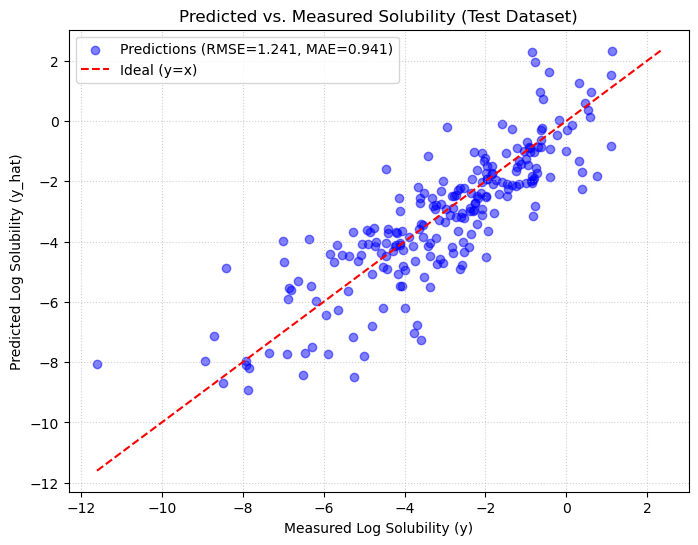

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

# 画散点图
plt.scatter(all_targets, all_preds, alpha=0.5, color='blue', label=f'Predictions (RMSE={rmse:.3f}, MAE={mae:.3f})')

# 画 45 度理想线
min_val = min(all_targets.min(), all_preds.min())
max_val = max(all_targets.max(), all_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal (y=x)')

plt.xlabel('Measured Log Solubility (y)')
plt.ylabel('Predicted Log Solubility (y_hat)')
plt.title('Predicted vs. Measured Solubility (Test Dataset)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()